In [6]:
#revisando data
import pandas as pd
import numpy as np
# Ejecuta esto para diagnosticar
print("=== DIAGNÓSTICO DEL PIPELINE ===")

# 1. Revisar data_cleaned
df_cleaned = pd.read_parquet('../data/processed/data_cleaned.parquet')
print(f"data_cleaned: {df_cleaned.shape}")

# 2. Revisar data_processed  - usaremos para el entrenamiento
df_processed = pd.read_parquet('../data/processed/data_processed.parquet')
print(f"data_processed: {df_processed.shape}")

# 4. Revisar datos originales
df_raw = pd.read_csv('../data/raw/retail_store_sales.csv')
print(f"data_sample (raw): {df_raw.shape}")

=== DIAGNÓSTICO DEL PIPELINE ===
data_cleaned: (12575, 11)
data_processed: (12575, 30)
data_sample (raw): (12575, 11)


✅ Precisión del modelo: 63.82%



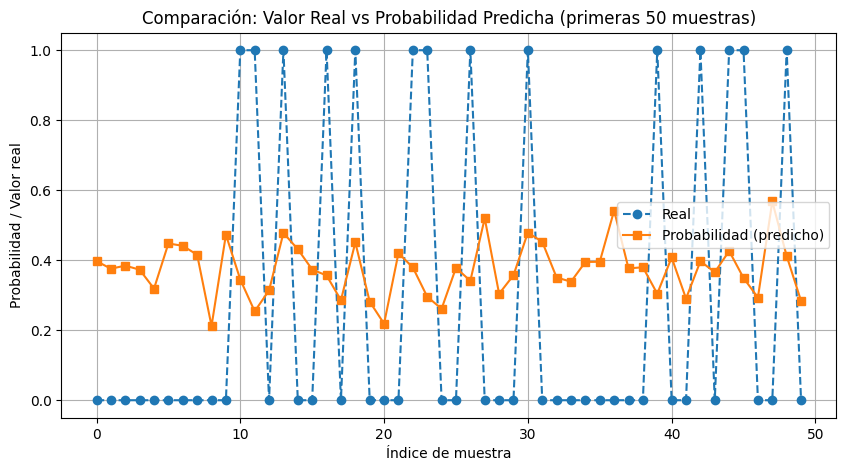

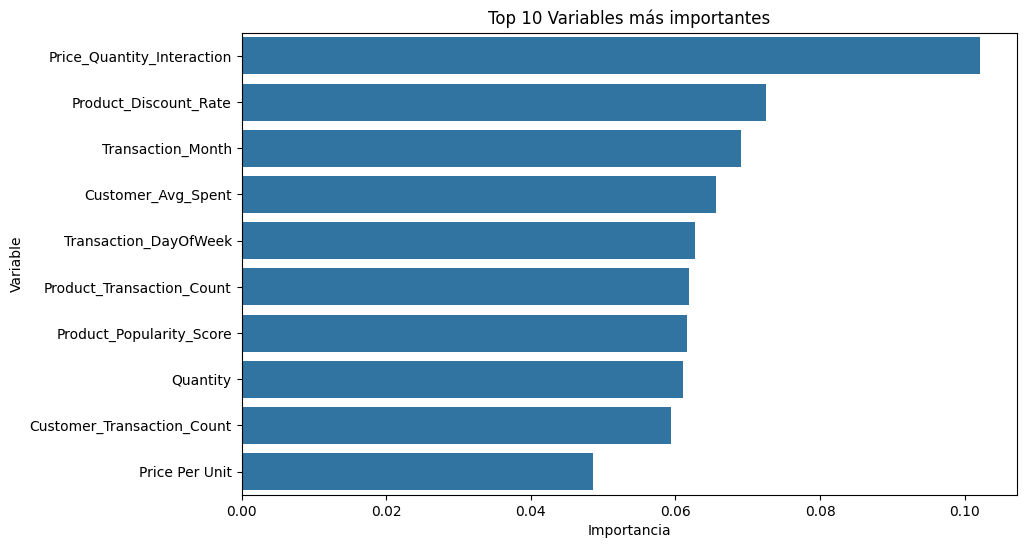

In [8]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Eliminar columnas no predictoras
X = df_processed.drop(['Discount Applied', 'Customer ID'], axis=1)
y = df_processed['Discount Applied']

# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar variables numéricas (no afecta las categóricas ya codificadas)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. ENTRENAR MODELO RANDOM FOREST
# ==========================================
model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# ==========================================
# 4. EVALUAR MODELO
# ==========================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Precisión del modelo: {accuracy*100:.2f}%\n")

# ==========================================
# 5. GRAFICAR PREDICCIONES (primeras 50 muestras)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Real', marker='o', linestyle='--')
plt.plot(y_prob[:50], label='Probabilidad (predicho)', marker='s')
plt.title("Comparación: Valor Real vs Probabilidad Predicha (primeras 50 muestras)")
plt.xlabel("Índice de muestra")
plt.ylabel("Probabilidad / Valor real")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 6. IMPORTANCIA DE VARIABLES
# ==========================================
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importances.head(10))
plt.title('Top 10 Variables más importantes')
plt.show()


⚡ Entrenando modelo XGBoost...


c:\Users\geral\Desktop\UPC\DataScience\upc_datasciense_202502_grupo02\myenv\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:49:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Precisión del modelo: 55.67%


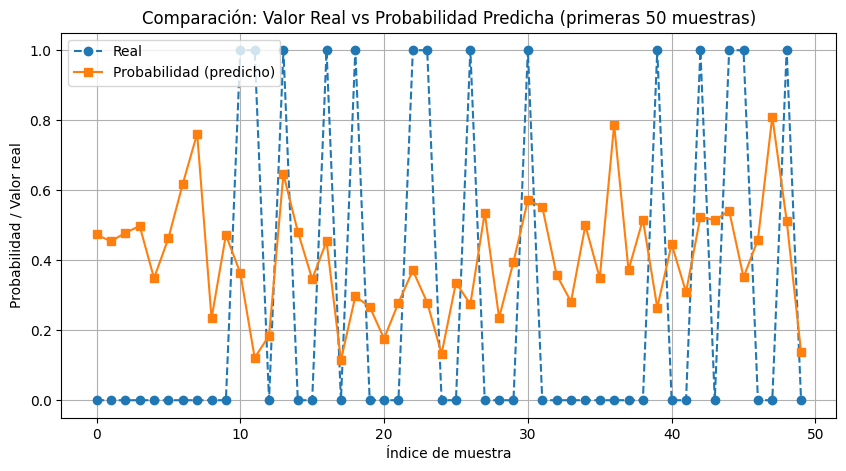

C:\Users\geral\AppData\Local\Temp\ipykernel_25948\1668456823.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importances.head(10), palette='viridis')


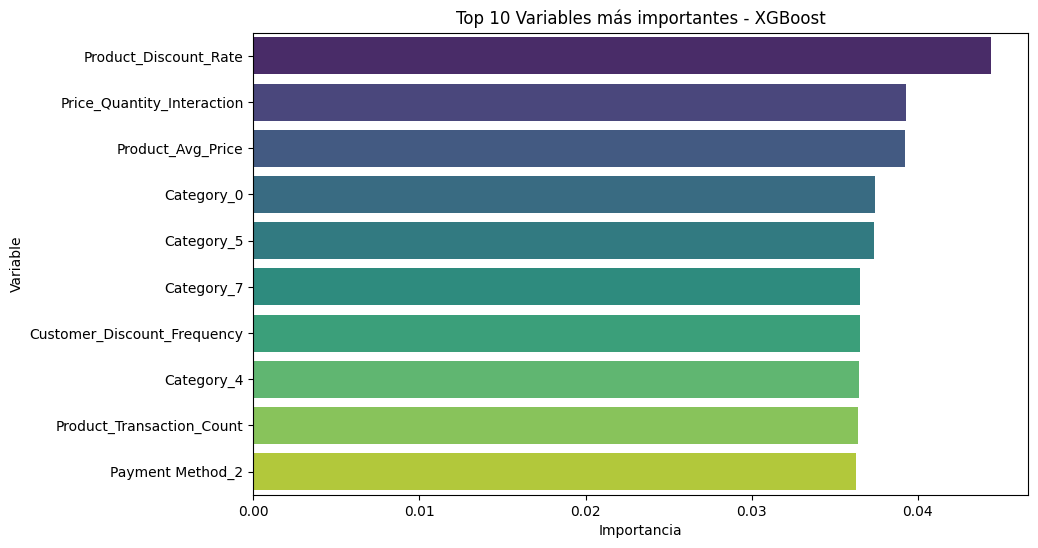


🏆 Top 10 variables más importantes:
                       Variable  Importancia
8         Product_Discount_Rate     0.044422
14   Price_Quantity_Interaction     0.039290
7             Product_Avg_Price     0.039230
15                   Category_0     0.037422
20                   Category_5     0.037381
22                   Category_7     0.036541
4   Customer_Discount_Frequency     0.036486
19                   Category_4     0.036479
6     Product_Transaction_Count     0.036422
27             Payment Method_2     0.036286


In [ ]:
# ==========================================
# 🚀 EXPERIMENTO XGBOOST - CLASIFICACIÓN DE DESCUENTOS
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)
from xgboost import XGBClassifier

# ==========================================
# 1. PREPARAR DATOS
# ==========================================
# Eliminar columnas no predictoras
X = df_processed.drop(['Discount Applied', 'Customer ID'], axis=1)
y = df_processed['Discount Applied']

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado (mantiene tu estilo anterior)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. ENTRENAR MODELO XGBOOST
# ==========================================
print("⚡ Entrenando modelo XGBoost...")

model = XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    reg_lambda=1.2,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_train_scaled, y_train)

# ==========================================
# 3. EVALUAR MODELO
# ==========================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("============================================================")
print(f"✅ Precisión del modelo: {accuracy * 100:.2f}%")

# ==========================================
# 5. GRAFICAR PREDICCIONES (primeras 50 muestras)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Real', marker='o', linestyle='--')
plt.plot(y_prob[:50], label='Probabilidad (predicho)', marker='s')
plt.title("Comparación: Valor Real vs Probabilidad Predicha (primeras 50 muestras)")
plt.xlabel("Índice de muestra")
plt.ylabel("Probabilidad / Valor real")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 6. IMPORTANCIA DE VARIABLES
# ==========================================
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importances.head(10), palette='viridis')
plt.title('Top 10 Variables más importantes - XGBoost')
plt.show()

print("\n🏆 Top 10 variables más importantes:")
print(importances.head(10))


🚀 Entrenando modelo CatBoost...
0:	learn: 0.6663022	test: 0.6644135	best: 0.6644135 (0)	total: 163ms	remaining: 1m 21s
100:	learn: 0.6940358	test: 0.6600398	best: 0.6652087 (29)	total: 1.77s	remaining: 6.98s
200:	learn: 0.7520875	test: 0.6576541	best: 0.6652087 (29)	total: 3.5s	remaining: 5.21s
300:	learn: 0.8087475	test: 0.6568588	best: 0.6652087 (29)	total: 5.05s	remaining: 3.34s
400:	learn: 0.8523857	test: 0.6489066	best: 0.6652087 (29)	total: 6.51s	remaining: 1.61s
499:	learn: 0.8868787	test: 0.6437376	best: 0.6652087 (29)	total: 8.15s	remaining: 0us

bestTest = 0.6652087475
bestIteration = 29

Shrink model to first 30 iterations.
✅ Precisión del modelo: 66.52%

📊 Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.66      1.00      0.80      1671
           1       1.00      0.00      0.00       844

    accuracy                           0.67      2515
   macro avg       0.83      0.50      0.40      2515
weighted avg       0.78  

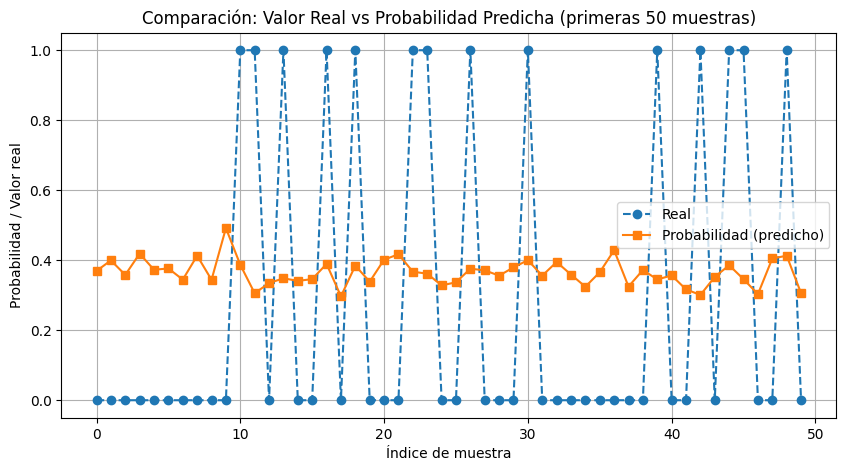

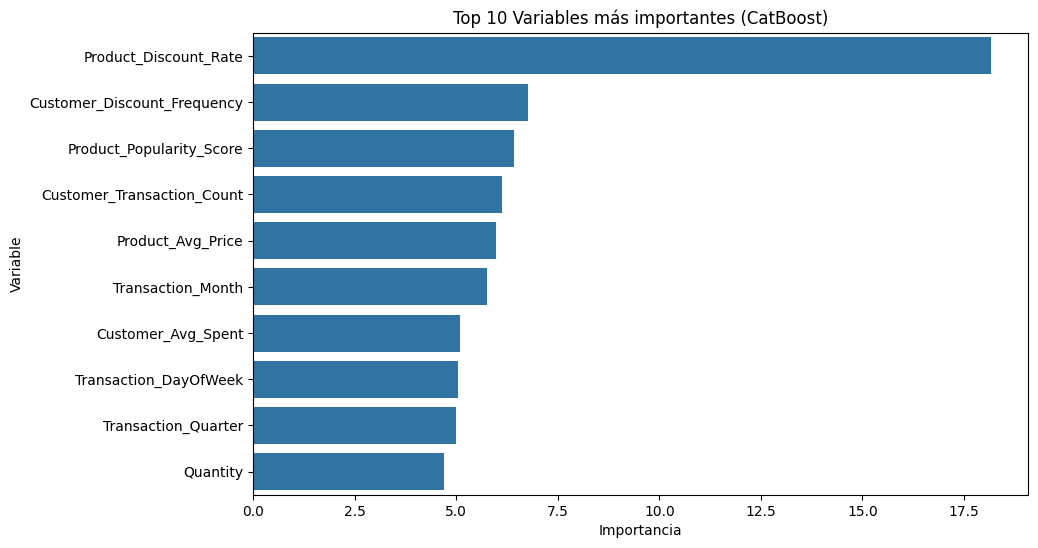

In [14]:
# ==========================================
# 1. IMPORTAR LIBRERÍAS
# ==========================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier

# ==========================================
# 2. PREPARAR DATOS
# ==========================================
# Suponiendo que ya tienes df_processed
# (y que incluye 'Discount Applied' como target)

X = df_processed.drop(['Discount Applied', 'Customer ID'], axis=1)
y = df_processed['Discount Applied']

# Dividir en entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar variables numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. ENTRENAR MODELO CATBOOST
# ==========================================
print("🚀 Entrenando modelo CatBoost...")

model = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    random_state=42,
    verbose=100
)

model.fit(X_train_scaled, y_train, eval_set=(X_test_scaled, y_test))

# ==========================================
# 4. EVALUAR MODELO
# ==========================================
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print("============================================================")
print(f"✅ Precisión del modelo: {accuracy * 100:.2f}%")
print("\n📊 Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# ==========================================
# 5. GRAFICAR PREDICCIONES (primeras 50 muestras)
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:50], label='Real', marker='o', linestyle='--')
plt.plot(y_prob[:50], label='Probabilidad (predicho)', marker='s')
plt.title("Comparación: Valor Real vs Probabilidad Predicha (primeras 50 muestras)")
plt.xlabel("Índice de muestra")
plt.ylabel("Probabilidad / Valor real")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 6. IMPORTANCIA DE VARIABLES
# ==========================================
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.get_feature_importance()
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importances.head(10))
plt.title('Top 10 Variables más importantes (CatBoost)')
plt.show()
